## 07. Post Perturbation Analysis Tutorial

In this notebook, we examine transcriptomic changes following in silico perturbation.
The output of the PerturbGen in-silico module (Notebook 6) is an `.h5ad` file with:

- **`X`**: perturbed (KO) predicted counts
- **`layers['pred_counts']`**: matched control (unperturbed) predicted counts
- **`layers['true_counts']`**: measured target counts (optional sanity check)
- **`obsm['mean_cos_similarity']`**: mean token-embedding cosine similarity (control vs KO)
- **`uns['gene_cos_similarity']`**: optional token-level gene cosine similarities (not used below)

Counts in `X` / layers are raw-scale model outputs and should be normalized + log-transformed before DEG / enrichment analysis.


Load the libraries

In [2]:
from pathlib import Path

import anndata as ad
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display

WORKSPACE = Path("/home/stuke1/perturbgen")
REPO = WORKSPACE / "Perturbgen"
PERT_DIR = WORKSPACE / "T_perturb" / "res" / "perturbation" / "il1b_src_90m"
# IL1B src-KO inference output from notebook 06
PERT_H5AD = sorted(PERT_DIR.glob("*_minference_adata_gENSG00000125538_ssrc_tmask.h5ad"))[-1]
# Full LPS reference AnnData (used only for Ensembl -> gene symbol mapping)
FULL_H5AD = REPO / "docs" / "examples" / "lps_otar.h5ad"
FIG_DIR = PERT_DIR / "post_analyses"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PERT_H5AD:", PERT_H5AD)
print("FULL_H5AD:", FULL_H5AD)
assert PERT_H5AD.is_file(), PERT_H5AD
assert FULL_H5AD.is_file(), FULL_H5AD


PERT_H5AD: /home/stuke1/perturbgen/T_perturb/res/perturbation/il1b_src_90m/20260810-17:12_minference_adata_gENSG00000125538_ssrc_tmask.h5ad
FULL_H5AD: /home/stuke1/perturbgen/Perturbgen/docs/examples/lps_otar.h5ad


Load the `.h5ad` object containing the results of the in-silico perturbation (notebook 06).


In [3]:
adata = sc.read(PERT_H5AD)
print(adata)
print(adata.obs["time_after_LPS"].value_counts())
print(adata.obs["cell_type_harmonized"].value_counts().head(10))


AnnData object with n_obs × n_vars = 20783 × 2000
    obs: 'cell_type_harmonized', 'cell_pairing_index', 'time_after_LPS', 'cell_idx'
    uns: 'gene_cos_similarity', 'gene_cos_similarity_genes'
    obsm: 'mean_cos_similarity', 'perturbed_cls', 'true_cls'
    layers: 'pred_counts', 'true_counts'
time_after_LPS
6h_LPS     11808
10h_LPS     8975
Name: count, dtype: int64
cell_type_harmonized
CD14 monocytes                 18253
Dendritic cells                  861
CD8+ T cells                     368
NK                               359
CD16 monocytes                   312
CD4+ T cells                     289
B cell                           138
Plasmocytoid dendritic cell       62
hematopoietic stem cell           57
platelet                          53
Name: count, dtype: int64


As noted earlier, perturbed gene expression counts are stored in `.X`, while unperturbed (predicted) counts are stored in `layers['pred_counts']`. To organize these data, we construct a new `AnnData` object with the following annotations:

- **`status`**: indicates whether a cell is perturbed or unperturbed  
- **`status_time`**: records the perturbation status at each timepoint

In [4]:
pred = adata.copy()
pred.X = pred.layers['pred_counts'].copy()

In [5]:
pred.obs['status'] = 'unperturbed'
adata.obs['status'] = 'perturbed'

In [6]:
adata.obs['status_time'] = 'perturbed_' + adata.obs['time_after_LPS'].astype(str)
pred.obs['status_time'] = 'unperturbed_' + pred.obs['time_after_LPS'].astype(str)

In [7]:
# Combine perturbed (X) and unperturbed (pred_counts) as two status groups
adata = ad.concat(
    {"perturbed": adata, "unperturbed": pred},
    label="batch_status",
    index_unique="-",
)
print(adata)
print(adata.obs["status"].value_counts())
print(adata.obs["status_time"].value_counts())


AnnData object with n_obs × n_vars = 41566 × 2000
    obs: 'cell_type_harmonized', 'cell_pairing_index', 'time_after_LPS', 'cell_idx', 'status', 'status_time', 'batch_status'
    obsm: 'mean_cos_similarity', 'perturbed_cls', 'true_cls'
    layers: 'pred_counts', 'true_counts'
status
perturbed      20783
unperturbed    20783
Name: count, dtype: int64
status_time
perturbed_6h_LPS       11808
unperturbed_6h_LPS     11808
perturbed_10h_LPS       8975
unperturbed_10h_LPS     8975
Name: count, dtype: int64


The predicted counts for both the unperturbed and perturbed conditions are stored in their raw form. Therefore, it is necessary to normalize and log-transform these counts prior to downstream analyses.

In [8]:
sc.pp.normalize_total(adata) # normalize total counts per cell
sc.pp.log1p(adata) # log-transform the data

Optionally rename cell types for plot labels.

In [9]:
ct_map = {
    "B cell": "B cells",
    "CD14 monocytes": "CD14+ monocytes",
    "CD16 monocytes": "CD16+ monocytes",
    "CD4+ T cells": "CD4+ T cells",
    "CD8+ T cells": "CD8+ T cells",
    "Dendritic cells": "Dendritic cells",
    "NK": "NK cells",
    "NKT": "NKT cells",
    "Plasmocytoid dendritic cell": "Plasmacytoid dendritic cells",
    "hematopoietic stem cell": "Hematopoietic stem cells",
    "platelet": "Platelets",
}

adata.obs["cell_type_harmonized"] = (
    adata.obs["cell_type_harmonized"]
    .astype(str)
    .map(lambda x: ct_map.get(x, x))
    .astype("category")
)
print(adata.obs["cell_type_harmonized"].value_counts())


cell_type_harmonized
CD14+ monocytes                 36506
Dendritic cells                  1722
CD8+ T cells                      736
NK cells                          718
CD16+ monocytes                   624
CD4+ T cells                      578
B cells                           276
Plasmacytoid dendritic cells      124
Hematopoietic stem cells          114
Platelets                         106
NKT cells                          62
Name: count, dtype: int64


Here, we evaluate the number of significant differentially expressed genes (DEGs) for each cell type by comparing perturbed counts with unperturbed counts. We refer to this measure as the perturbation effect.

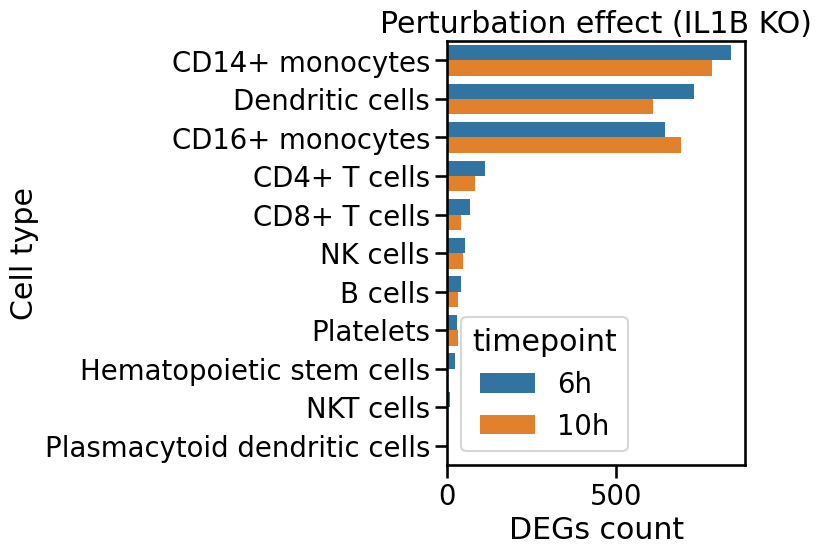

,cell_type,timepoint,deg_count
3,CD14+ monocytes,6h,842
14,CD14+ monocytes,10h,786
5,Dendritic cells,6h,732
15,CD16+ monocytes,10h,695
4,CD16+ monocytes,6h,646
16,Dendritic cells,10h,610
1,CD4+ T cells,6h,112
12,CD4+ T cells,10h,82
2,CD8+ T cells,6h,66
6,NK cells,6h,52


In [10]:
cell_types = adata.obs["cell_type_harmonized"].unique()
timepoints = ["6h_LPS", "10h_LPS"]
results = []

for tp in timepoints:
    unperturbed = f"unperturbed_{tp}"
    perturbed = f"perturbed_{tp}"

    for ct in cell_types:
        mask_pert = (adata.obs["status_time"] == perturbed) & (
            adata.obs["cell_type_harmonized"] == ct
        )
        mask_unpt = (adata.obs["status_time"] == unperturbed) & (
            adata.obs["cell_type_harmonized"] == ct
        )

        if mask_pert.sum() == 0 or mask_unpt.sum() == 0:
            continue

        sub_adata = adata[mask_pert | mask_unpt].copy()
        sub_adata.obs["group"] = "unperturbed"
        sub_adata.obs.loc[sub_adata.obs["status_time"] == perturbed, "group"] = "perturbed"
        sub_adata.obs["group"] = sub_adata.obs["group"].astype("category")

        sc.tl.rank_genes_groups(
            sub_adata,
            groupby="group",
            reference="unperturbed",
            method="wilcoxon",
        )
        degs = sc.get.rank_genes_groups_df(sub_adata, group="perturbed")
        deg_count = int((degs["pvals_adj"] < 0.05).sum())
        results.append({"cell_type": ct, "timepoint": tp, "deg_count": deg_count})

df = pd.DataFrame(results)
df_sorted = df.sort_values(by="deg_count", ascending=False)
df_sorted["timepoint"] = df_sorted["timepoint"].replace(
    {"6h_LPS": "6h", "10h_LPS": "10h"}
)
df_sorted.to_csv(FIG_DIR / "deg_counts_by_celltype.csv", index=False)

sns.set_context("talk", font_scale=1.2)
plt.figure(figsize=(8, 6))
sns.barplot(data=df_sorted, y="cell_type", x="deg_count", hue="timepoint")
plt.ylabel("Cell type")
plt.xlabel("DEGs count")
plt.title("Perturbation effect (IL1B KO)")
plt.tight_layout()
plt.savefig(FIG_DIR / "deg_counts_by_celltype.png", dpi=150, bbox_inches="tight")
plt.show()
display(df_sorted)


Next, we subset the data to the myeloid lineage, which exhibits the strongest perturbation effect. Depending on the analysis goals, the data can alternatively be subset to any other affected cell types or lineages of interest.

In [11]:
MYELOID = ["CD14+ monocytes", "Dendritic cells", "CD16+ monocytes"]
adata = adata[adata.obs["cell_type_harmonized"].isin(MYELOID)].copy()
print(adata)
print(adata.obs["cell_type_harmonized"].value_counts())


AnnData object with n_obs × n_vars = 38852 × 2000
    obs: 'cell_type_harmonized', 'cell_pairing_index', 'time_after_LPS', 'cell_idx', 'status', 'status_time', 'batch_status'
    uns: 'log1p'
    obsm: 'mean_cos_similarity', 'perturbed_cls', 'true_cls'
    layers: 'pred_counts', 'true_counts'
cell_type_harmonized
CD14+ monocytes    36506
Dendritic cells     1722
CD16+ monocytes      624
Name: count, dtype: int64


Because `var_names` in the perturbation AnnData are Ensembl IDs, we load the original LPS reference (`lps_otar.h5ad`) **only to read its gene annotation table** and map Ensembl → gene symbols for enrichment.


In [12]:
# Backed read: only need .var for symbol mapping (avoid loading full expression matrix)
adata_full = ad.read_h5ad(FULL_H5AD, backed="r")
print(adata_full)
print("var columns:", list(adata_full.var.columns)[:8], "...")


AnnData object with n_obs × n_vars = 223478 × 13826 backed at '/home/stuke1/perturbgen/Perturbgen/docs/examples/lps_otar.h5ad'
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_

Build an Ensembl → symbol map from the reference `.var` table. (`lps_otar` already uses Ensembl IDs as `var_names`; symbols live in `gene_symbol-0` / `gene_ids-0`.)


In [13]:
# Prefer gene_symbol-0; fall back to gene_ids-0
sym_col = "gene_symbol-0" if "gene_symbol-0" in adata_full.var.columns else "gene_ids-0"
ens2sym = adata_full.var[sym_col].astype(str).to_dict()  # index = Ensembl ID
adata_full.file.close()
print("Mapped symbols:", len(ens2sym), "| example IL1B:", ens2sym.get("ENSG00000125538"))


Mapped symbols: 13826 | example IL1B: IL1B


Map perturbation `var_names` from Ensembl IDs to gene symbols (required for GSEApy gene-set libraries).


In [14]:
adata.var["ensembl_id"] = adata.var_names.astype(str)
adata.var["gene_symbol"] = adata.var["ensembl_id"].map(ens2sym)
n_missing = int(adata.var["gene_symbol"].isna().sum())
print(f"Unmapped genes: {n_missing}/{adata.n_vars}")
adata = adata[:, adata.var["gene_symbol"].notna()].copy()
adata.var_names = adata.var["gene_symbol"].astype(str)
adata.var_names_make_unique()
print(adata)
print("IL1B in var_names:", "IL1B" in set(adata.var_names))


Unmapped genes: 0/2000
AnnData object with n_obs × n_vars = 38852 × 2000
    obs: 'cell_type_harmonized', 'cell_pairing_index', 'time_after_LPS', 'cell_idx', 'status', 'status_time', 'batch_status'
    var: 'ensembl_id', 'gene_symbol'
    uns: 'log1p'
    obsm: 'mean_cos_similarity', 'perturbed_cls', 'true_cls'
    layers: 'pred_counts', 'true_counts'
IL1B in var_names: True


Myeloid DEGs at 6h / 10h (perturbed vs unperturbed predictions) for enrichment.


In [15]:
# (gene mapping already applied above)
print("Ready for myeloid DEG + enrichment. n_obs x n_vars =", adata.shape)


Ready for myeloid DEG + enrichment. n_obs x n_vars = (38852, 2000)


We compute DEGs within the myeloid subset at each timepoint (perturbed vs unperturbed as reference), then split significant genes into up- and down-regulated sets for enrichment.


In [16]:
deg_results = {}

for tp in ["6h", "10h"]:
    pert = f"perturbed_{tp}_LPS"
    unpert = f"unperturbed_{tp}_LPS"

    ad_sub = adata[adata.obs["status_time"].isin([pert, unpert])].copy()
    ad_sub.obs["cond"] = (
        ad_sub.obs["status_time"].map({pert: "pert", unpert: "unpert"}).astype("category")
    )

    sc.tl.rank_genes_groups(
        ad_sub,
        groupby="cond",
        groups=["pert"],
        reference="unpert",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
    )

    de = sc.get.rank_genes_groups_df(ad_sub, group="pert")
    de.to_csv(FIG_DIR / f"myeloid_degs_{tp}.csv", index=False)

    sig = de[de["pvals_adj"] < 0.05]
    up = sig[sig["logfoldchanges"] > 0]
    down = sig[sig["logfoldchanges"] < 0]
    deg_results[tp] = {"up": up["names"].tolist(), "down": down["names"].tolist()}
    print(f"{tp}: n={ad_sub.n_obs}, sig={len(sig)}, up={len(up)}, down={len(down)}")


6h: n=22192, sig=894, up=433, down=461
10h: n=16660, sig=822, up=353, down=469


Use GSEApy / Enrichr for pathway enrichment on the DEG lists (needs network access).
Reference: Fang et al., 2023 (GSEApy).


In [17]:
# Enrichr gene-set libraries require outbound network access.
# Pick libraries that actually exist on the Enrichr server (names change between years).
PREFERRED_LIBS = {
    "reactome": ["Reactome_Pathways_2024", "Reactome_2022"],
    "go_bp": ["GO_Biological_Process_2025", "GO_Biological_Process_2023"],
}
try:
    available = set(gp.get_library_name(organism="Human"))
    gene_sets = [
        next(lib for lib in libs if lib in available)
        for libs in PREFERRED_LIBS.values()
    ]
except Exception as e:
    print(f"Could not list Enrichr libraries ({e}); using defaults")
    gene_sets = ["Reactome_2022", "GO_Biological_Process_2023"]
print("Using gene sets:", gene_sets)

for tp, res in deg_results.items():
    for label, genes in res.items():
        if len(genes) == 0:
            print(f"Skip {tp} {label}: empty gene list")
            continue

        # background= uses a different Enrichr endpoint that is often flaky;
        # try with background first, fall back to plain enrichr.
        enr = None
        try:
            enr = gp.enrichr(
                gene_list=genes,
                gene_sets=gene_sets,
                organism="Human",
                outdir=None,
                background=list(adata.var_names),
            )
        except Exception as e:
            print(f"{tp} {label}: background mode failed ({e}); retrying without background")
            try:
                enr = gp.enrichr(
                    gene_list=genes,
                    gene_sets=gene_sets,
                    organism="Human",
                    outdir=None,
                )
            except Exception as e2:
                print(f"{tp} {label}: enrichr failed entirely ({e2}); skipping")
                continue

        if enr is None or enr.results is None or len(enr.results) == 0:
            print(f"{tp} {label}: no enrichment results")
            continue

        df_enr = enr.results.sort_values("Adjusted P-value").head(15).copy()
        df_enr.to_csv(FIG_DIR / f"enrichr_{tp}_{label}.csv", index=False)

        # Plot manually (gp.barplot raises if nothing passes its internal cutoff)
        df_plot = df_enr.iloc[::-1]
        neglogp = -np.log10(df_plot["Adjusted P-value"].clip(lower=1e-300))
        terms = df_plot["Term"].str.slice(0, 60)
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.barh(terms, neglogp, color="#2166ac" if label == "up" else "#b2182b")
        ax.axvline(-np.log10(0.05), color="k", ls="--", lw=0.8, label="FDR 0.05")
        ax.set_xlabel(r"$-\log_{10}$ adjusted P-value")
        ax.set_title(f"IL1B KO | {tp} {label.upper()}")
        ax.legend(fontsize=8)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"enrichr_{tp}_{label}.png", dpi=150, bbox_inches="tight")
        plt.show()


JSONDecodeError: Expecting value: line 1 column 7603 (char 7602)